# Linear Spin-Wave Theory $J_1$-$J_2$ yang Diaudit

Notebook ini mengimplementasikan **Linear Spin-Wave Theory (LSWT)** untuk rantai spin satu dimensi dengan satu spin per primitive cell,

$$
H=\sum_i\left[J_1\mathbf S_i\cdot\mathbf S_{i+1}+J_2\mathbf S_i\cdot\mathbf S_{i+2}\right],
$$

dan konfigurasi klasik spiral pada bidang laboratorium $xz$,

$$
\mathbf S_i^{\rm cl}=S(\sin Qi,0,\cos Qi)^T.
$$

Tujuan notebook ini adalah memperoleh ground state klasik global, Hamiltonian bosonik BdG yang konsisten, eigensystem bosonik ter-normalisasi, matrix element spin satu-magnon, $S^{\alpha\beta}(q,\omega)$, serta intensitas neutron dengan status form factor dan polarization factor yang eksplisit.


## 1. Ringkasan audit notebook lama

Audit dilakukan terhadap seluruh 19 cell, source code, parameter, execution count, dan output lama.

- **Konvensi tanda:** notebook memakai $H=+J_d\mathbf S_i\cdot\mathbf S_{i+d}$. Karena itu $J_d>0$ cenderung antiferomagnetik dan $J_d<0$ cenderung feromagnetik.
- **Penghitungan bond:** $d=1$ dan $d=2$ masing-masing dijumlahkan sekali melalui $\sum_i$; tidak diperlukan prefaktor $1/2$.
- **Satuan:** $J_1,J_2,\omega,T$ dipakai dalam satuan energi yang sama, dengan $\hbar=k_B=1$ secara default. Momentum dinyatakan dalam $1/a$.
- **Fourier:** notebook lama memakai $a_j=N^{-1/2}\sum_qe^{iqR_j}a_q$, tetapi grid $[0,2\pi]$ memasukkan dua endpoint periodik yang sama.
- **Basis Nambu:** $(a_q,a_{-q}^\dagger)^T$ sudah dinyatakan, tetapi pemilihan mode fisik dan normalisasi metrik belum diterapkan lengkap.
- **BdG:** bentuk $\begin{pmatrix}A&B\\B&A\end{pmatrix}$ sesuai untuk model real dan inversion-symmetric ini. Bentuk $A(q),B(q)$ lama benar di bawah konvensi tersebut, tetapi belum diverifikasi terhadap bentuk compact $J(k)$.
- **Ground state:** fallback `Q = 0` ketika solusi spiral tidak valid salah karena minimum global dapat berada di $Q=\pi$.
- **Eigensystem:** kode lama menyortir eigenvalue saja; ia tidak memilih mode berdasarkan energi **dan** tanda norm bosonik, tidak mengecek residual, pasangan $\pm\varepsilon$, atau paraunitarity.
- **Goldstone:** `if epsilon > 1e-10` menghapus mode nol dari peta intensitas. Fungsi Bose lama juga mengganti limit energi kecil menjadi nol tanpa regularisasi yang terdokumentasi.
- **Intensitas:** $W_n(q)=1$ merupakan bobot fenomenologis. Tidak ada operator spin laboratorium, matrix element, tensor $S^{\alpha\beta}$, atau selection rule.
- **$S^{zz}$:** notebook lama tidak membedakan longitudinal local-frame response dari komponen laboratorium. Local $\widetilde S^{zz}$ tidak memiliki satu-magnon pada LSWT, tetapi lab $S^{zz}$ dapat memilikinya untuk spiral nonkolinear.
- **Form factor:** $e^{-0.1q^2}$ dipakai seolah fisik walaupun hanya toy model dan bergantung pada reduced momentum, bukan absolute $|\mathbf Q|$.
- **Polarization factor:** belum ada dan geometri tiga dimensi belum dimasukkan.
- **Output:** execution count tidak berurutan, output lama tidak membuktikan sinkronisasi penuh, tidak ada plot validasi, dan file CSV ditulis ke working directory tanpa mencetak path absolut.
- **Kode tidak terpakai/kurang modular:** eigenvector hasil `eig` tidak pernah dipakai untuk intensitas; fungsi normalisasi tidak pernah dipanggil pada hasil akhir; tidak ada type hints, docstring, input validation, atau automated tests.

Notebook baru di bawah mengganti seluruh pipeline tersebut. Tidak ada output notebook lama yang dipertahankan.


## 2. Konvensi model dan numerik

Konvensi yang dipakai di seluruh notebook:

$$
H=\sum_i\sum_{d=1,2}J_d\mathbf S_i\cdot\mathbf S_{i+d},
\qquad J_1\equiv J_{d=1},\quad J_2\equiv J_{d=2}.
$$

Setiap physical bond arah positif dihitung sekali. Posisi $R_i=ia$. Fourier transform:

$$
a_i=\frac1{\sqrt N}\sum_qe^{iqR_i}a_q,
\qquad
a_i^\dagger=\frac1{\sqrt N}\sum_qe^{-iqR_i}a_q^\dagger.
$$

Brillouin zone utama adalah $[-\pi/a,\pi/a)$. Grid dibuat periodik, tidak menduplikasi endpoint, dan sengaja memuat $q=0$. Spin magnitude $S$ tidak dibatasi pada $1/2$.


In [1]:
"""Core numerical routines for the audited J1-J2 linear spin-wave notebook."""

from __future__ import annotations

from collections.abc import Callable
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import scipy.linalg as la


Array = np.ndarray


@dataclass(frozen=True)
class ModelParameters:
    """Physical parameters for the one-dimensional J1-J2 model."""

    S: float
    J1: float
    J2: float
    lattice_constant: float = 1.0


@dataclass(frozen=True)
class NumericalParameters:
    """Numerical controls used by the LSWT and spectral calculations."""

    n_q: int = 501
    n_omega: int = 600
    omega_max: float | None = None
    broadening: float = 0.03
    temperature: float = 0.0
    tolerance: float = 1.0e-10
    k_B: float = 1.0
    goldstone_regularization: float = 1.0e-6


def _require_finite(name: str, value: float) -> None:
    if not np.isfinite(value):
        raise ValueError(f"{name} must be finite; received {value!r}.")


def validate_parameters(model: ModelParameters, numerical: NumericalParameters) -> None:
    """Validate model and numerical inputs before any calculation."""

    for name, value in (
        ("S", model.S),
        ("J1", model.J1),
        ("J2", model.J2),
        ("lattice_constant", model.lattice_constant),
        ("broadening", numerical.broadening),
        ("temperature", numerical.temperature),
        ("tolerance", numerical.tolerance),
        ("k_B", numerical.k_B),
        ("goldstone_regularization", numerical.goldstone_regularization),
    ):
        _require_finite(name, float(value))

    if model.S <= 0.0:
        raise ValueError("S must be strictly positive.")
    if model.lattice_constant <= 0.0:
        raise ValueError("lattice_constant must be strictly positive.")
    if numerical.n_q < 3:
        raise ValueError("n_q must be at least 3.")
    if numerical.n_omega < 3:
        raise ValueError("n_omega must be at least 3.")
    if numerical.broadening <= 0.0:
        raise ValueError("broadening must be strictly positive.")
    if numerical.temperature < 0.0:
        raise ValueError("temperature cannot be negative.")
    if numerical.tolerance <= 0.0:
        raise ValueError("tolerance must be strictly positive.")
    if numerical.k_B <= 0.0:
        raise ValueError("k_B must be strictly positive.")
    if numerical.goldstone_regularization <= 0.0:
        raise ValueError("goldstone_regularization must be strictly positive.")
    if numerical.omega_max is not None:
        _require_finite("omega_max", float(numerical.omega_max))
        if numerical.omega_max <= 0.0:
            raise ValueError("omega_max must be positive when provided.")


def wrap_momentum(q: float | Array, lattice_constant: float = 1.0) -> float | Array:
    """Wrap momentum to the principal Brillouin zone [-pi/a, pi/a)."""

    period = 2.0 * np.pi / lattice_constant
    wrapped = (np.asarray(q, dtype=float) + 0.5 * period) % period - 0.5 * period
    return float(wrapped) if wrapped.ndim == 0 else wrapped


def centered_q_grid(n_q: int, lattice_constant: float = 1.0) -> Array:
    """Return a uniform periodic grid that contains q=0 and no duplicate endpoint."""

    indices = np.arange(n_q, dtype=float) - n_q // 2
    return (2.0 * np.pi / (n_q * lattice_constant)) * indices




from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8.0, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

print(f"NumPy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"SciPy      : {__import__('scipy').__version__}")
print(f"Matplotlib : {matplotlib.__version__}")


NumPy      : 2.3.5
pandas     : 3.0.3
SciPy      : 1.17.0
Matplotlib : 3.10.7


## 3. Parameter model dan parameter numerik

`omega_max=None` berarti batas energi dipilih otomatis dari energi mode maksimum ditambah margin broadening. `goldstone_regularization` **tidak** mengubah dispersi fisik; ia hanya dipakai ketika eigenvector zero-norm tepat pada mode Goldstone atau ketika Bose factor dievaluasi pada energi nol.

Default form factor adalah `none`, sehingga tidak ada fungsi ion magnetik fiktif. Default polarization adalah `none` karena reduced momentum satu dimensi belum menentukan vektor transfer momentum tiga dimensi.


In [2]:
# -------------------------
# Physical model parameters
# -------------------------
S = 1.0
J1 = 1.0
J2 = 0.5
lattice_constant = 1.0

# --------------------
# Numerical parameters
# --------------------
n_q = 501
n_omega = 600
omega_max = None
broadening = 0.03
temperature = 0.0
tolerance = 1.0e-10
k_B = 1.0
goldstone_regularization = 1.0e-6

broadening_kind = "gaussian"       # "gaussian" or "lorentzian"
form_factor_mode = "none"          # "none", "toy_gaussian", or "custom"
toy_form_factor_width = 0.1         # used only by the explicitly nonphysical toy mode
absolute_q_vectors = None           # optional array with shape (n_q, 3)

model = ModelParameters(S=S, J1=J1, J2=J2, lattice_constant=lattice_constant)
numerical = NumericalParameters(
    n_q=n_q,
    n_omega=n_omega,
    omega_max=omega_max,
    broadening=broadening,
    temperature=temperature,
    tolerance=tolerance,
    k_B=k_B,
    goldstone_regularization=goldstone_regularization,
)
validate_parameters(model, numerical)

print(model)
print(numerical)
print(f"Broadening mode : {broadening_kind}")
print(f"Form factor mode: {form_factor_mode}")
print(f"Polarization    : {'disabled' if absolute_q_vectors is None else 'user-supplied 3D Q'}")


ModelParameters(S=1.0, J1=1.0, J2=0.5, lattice_constant=1.0)
NumericalParameters(n_q=501, n_omega=600, omega_max=None, broadening=0.03, temperature=0.0, tolerance=1e-10, k_B=1.0, goldstone_regularization=1e-06)
Broadening mode : gaussian
Form factor mode: none
Polarization    : disabled


## 4. Ground state klasik global

Energi klasik per spin:

$$
\frac{E_{\rm cl}(Q)}N=S^2[J_1\cos Q+J_2\cos(2Q)].
$$

Stationary candidates:

$$Q=0,\qquad Q=\pi,$$

dan, bila $J_2\neq0$ serta nilai ruas kanan berada pada $[-1,1]$,

$$\cos Q=-\frac{J_1}{4J_2}.$$

Semua kandidat valid dievaluasi dan minimum global dipilih. Kandidat spiral tidak otomatis dipilih hanya karena persamaannya memiliki solusi. Titik-titik yang ekuivalen modulo $2\pi$ dideduplikasi dan degenerasi energi dilaporkan.


Classical phase  : spiral
Pitch Q          : 2.094395102393 rad/site
Classical energy : -0.750000000000 per spin
dE/dQ            : 2.220e-16
d2E/dQ2          : 1.500000000000
Selection note   : Unique minimum among the tested stationary candidates.


,phase,Q,energy,derivative,curvature
0,ferromagnetic,0.000000,1.50,-0.000000e+00,-3.0
1,antiferromagnetic,3.141593,-0.50,1.224647e-16,-1.0
2,spiral,2.094395,-0.75,2.220446e-16,1.5


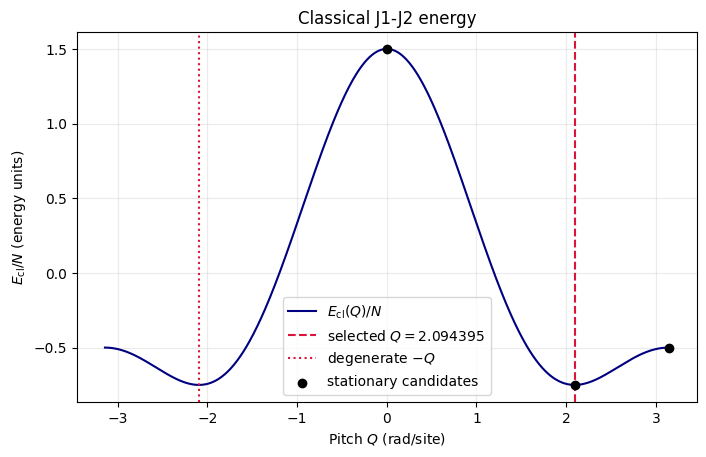

In [3]:
def classical_energy(Q: float | Array, S: float, J1: float, J2: float) -> float | Array:
    """Classical energy per spin for a uniform pitch Q (radians per site)."""

    Q_array = np.asarray(Q, dtype=float)
    energy = S**2 * (J1 * np.cos(Q_array) + J2 * np.cos(2.0 * Q_array))
    return float(energy) if energy.ndim == 0 else energy


def classical_pitch_derivative(Q: float, S: float, J1: float, J2: float) -> float:
    """Return d(E_cl/N)/dQ."""

    return float(-S**2 * (J1 * np.sin(Q) + 2.0 * J2 * np.sin(2.0 * Q)))


def classical_pitch_curvature(Q: float, S: float, J1: float, J2: float) -> float:
    """Return d^2(E_cl/N)/dQ^2."""

    return float(-S**2 * (J1 * np.cos(Q) + 4.0 * J2 * np.cos(2.0 * Q)))


def find_classical_ground_state(
    S: float,
    J1: float,
    J2: float,
    tolerance: float = 1.0e-12,
) -> dict[str, Any]:
    """Select the global minimum among FM, AF, and valid spiral candidates."""

    for name, value in (("S", S), ("J1", J1), ("J2", J2), ("tolerance", tolerance)):
        _require_finite(name, float(value))
    if S <= 0.0:
        raise ValueError("S must be strictly positive.")
    if tolerance <= 0.0:
        raise ValueError("tolerance must be strictly positive.")

    raw_candidates: list[tuple[str, float]] = [
        ("ferromagnetic", 0.0),
        ("antiferromagnetic", np.pi),
    ]
    boundary_message = ""

    if abs(J2) > tolerance:
        cos_Q = -J1 / (4.0 * J2)
        if abs(cos_Q) <= 1.0 + tolerance:
            clipped = float(np.clip(cos_Q, -1.0, 1.0))
            raw_candidates.append(("spiral", float(np.arccos(clipped))))
            if abs(abs(cos_Q) - 1.0) <= 100.0 * tolerance:
                boundary_message = "The parameters lie on (or numerically extremely near) a phase boundary."

    candidates: list[dict[str, Any]] = []
    angle_tolerance = max(100.0 * tolerance, 1.0e-10)
    for label, Q in raw_candidates:
        canonical_Q = float(np.arccos(np.clip(np.cos(Q), -1.0, 1.0)))
        if any(abs(canonical_Q - item["Q"]) <= angle_tolerance for item in candidates):
            continue
        candidates.append(
            {
                "phase": label,
                "Q": canonical_Q,
                "energy": classical_energy(canonical_Q, S, J1, J2),
                "derivative": classical_pitch_derivative(canonical_Q, S, J1, J2),
                "curvature": classical_pitch_curvature(canonical_Q, S, J1, J2),
            }
        )

    minimum_energy = min(item["energy"] for item in candidates)
    energy_scale = max(1.0, S**2 * (abs(J1) + abs(J2)))
    degenerate = [
        item for item in candidates if abs(item["energy"] - minimum_energy) <= tolerance * energy_scale
    ]
    selected = min(degenerate, key=lambda item: item["Q"])

    Q_selected = float(selected["Q"])
    if abs(Q_selected) <= angle_tolerance:
        phase = "ferromagnetic"
    elif abs(Q_selected - np.pi) <= angle_tolerance:
        phase = "antiferromagnetic"
    else:
        phase = "spiral"

    messages: list[str] = []
    if len(degenerate) > 1:
        labels = ", ".join(f"{item['phase']} (Q={item['Q']:.12g})" for item in degenerate)
        messages.append(f"Degenerate classical minima: {labels}.")
    if boundary_message:
        messages.append(boundary_message)
    if abs(J1) <= tolerance and abs(J2) <= tolerance:
        messages.append("J1 and J2 both vanish within tolerance; the classical energy is flat in Q.")

    return {
        "Q": Q_selected,
        "energy": float(selected["energy"]),
        "phase": phase,
        "candidates": candidates,
        "degenerate": len(degenerate) > 1,
        "degenerate_candidates": degenerate,
        "message": " ".join(messages) if messages else "Unique minimum among the tested stationary candidates.",
        "pitch_derivative": classical_pitch_derivative(Q_selected, S, J1, J2),
        "pitch_curvature": classical_pitch_curvature(Q_selected, S, J1, J2),
    }


def rotation_y(angle: float) -> Array:
    """Local-to-laboratory rotation R_y(angle)."""

    c = np.cos(angle)
    s = np.sin(angle)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], dtype=float)




ground_state = find_classical_ground_state(S, J1, J2, tolerance)
Q = ground_state["Q"]
candidate_table = pd.DataFrame(ground_state["candidates"])

print(f"Classical phase  : {ground_state['phase']}")
print(f"Pitch Q          : {Q:.12f} rad/site")
print(f"Classical energy : {ground_state['energy']:.12f} per spin")
print(f"dE/dQ            : {ground_state['pitch_derivative']:.3e}")
print(f"d2E/dQ2          : {ground_state['pitch_curvature']:.12f}")
print(f"Selection note   : {ground_state['message']}")
display(candidate_table)

Q_plot = np.linspace(-np.pi, np.pi, 1601)
E_plot = classical_energy(Q_plot, S, J1, J2)
fig, ax = plt.subplots()
ax.plot(Q_plot, E_plot, color="navy", label=r"$E_{\rm cl}(Q)/N$")
ax.axvline(Q, color="crimson", linestyle="--", label=fr"selected $Q={Q:.6f}$")
if Q > tolerance and abs(Q - np.pi) > tolerance:
    ax.axvline(-Q, color="crimson", linestyle=":", label=r"degenerate $-Q$")
ax.scatter(candidate_table["Q"], candidate_table["energy"], color="black", zorder=4, label="stationary candidates")
ax.set(xlabel=r"Pitch $Q$ (rad/site)", ylabel=r"$E_{\rm cl}/N$ (energy units)", title="Classical J1-J2 energy")
ax.legend(loc="best")
plt.show()


## 5. Rotasi lokal, Holstein–Primakoff, dan suku linear

Spiral klasik berada pada bidang $xz$. Dipakai matriks **local-to-laboratory**

$$
\mathbf S_i=R_i\widetilde{\mathbf S}_i,
\qquad
R_i=R_y(Qi)=
\begin{pmatrix}
\cos Qi&0&\sin Qi\\
0&1&0\\
-\sin Qi&0&\cos Qi
\end{pmatrix}.
$$

Dengan demikian $\langle\widetilde{\mathbf S}_i\rangle=S\hat z$. Untuk bond $i\to i+d$,

$$R_i^TR_{i+d}=R_y(dQ).$$

Transformasi Holstein–Primakoff linear:

$$
\widetilde S_i^z=S-a_i^\dagger a_i,
\quad
\widetilde S_i^+\simeq\sqrt{2S}\,a_i,
\quad
\widetilde S_i^-\simeq\sqrt{2S}\,a_i^\dagger.
$$

Hamiltonian disusun sebagai

$$H=E_{\rm cl}+H_1+H_2+O(a^3).$$

Untuk rantai translationally invariant dengan bond kiri dan kanan yang simetris, local torque dari uniform-pitch spiral saling membatalkan untuk setiap $Q$; karena itu $H_1$ lokal dapat hilang bahkan pada spiral yang bukan minimum global. Pemilihan minimum global tetap dilakukan melalui $E_{\rm cl}(Q)$. Sebagai pemeriksaan tambahan dicetak residual $|dE_{\rm cl}/dQ|$.


## 6. Fourier transform dan penurunan $A(q),B(q)$

Untuk $c_d=\cos(dQ)$, Hamiltonian kuadratik satu jenis bond adalah

$$
H_d^{(2)}=\sum_i\left[
T_d(a_i^\dagger a_{i+d}+a_{i+d}^\dagger a_i)
+P_d(a_ia_{i+d}+a_i^\dagger a_{i+d}^\dagger)
-SJ_dc_d(n_i+n_{i+d})
\right],
$$

$$
T_d=\frac{SJ_d}{2}(1+c_d),
\qquad
P_d=\frac{SJ_d}{2}(c_d-1).
$$

Dengan Fourier convention notebook ini,

$$
\sum_i(a_i^\dagger a_{i+d}+a_{i+d}^\dagger a_i)
=2\sum_q\cos(qda)a_q^\dagger a_q,
$$

$$
\sum_i a_ia_{i+d}=\sum_q\cos(qda)a_qa_{-q}.
$$

Maka

$$
\boxed{A(q)=S\sum_{d=1,2}J_d[(1+\cos dQ)\cos(qda)-2\cos dQ]},
$$

$$
\boxed{B(q)=S\sum_{d=1,2}J_d(\cos dQ-1)\cos(qda)}.
$$

Definisikan

$$J(k)=J_1\cos(ka)+J_2\cos(2ka).$$

Kemudian

$$A(q)-B(q)=2S[J(q)-J(Q/a)],$$

$$A(q)+B(q)=S[J(q+Q/a)+J(q-Q/a)-2J(Q/a)],$$

sehingga

$$
\boxed{
\varepsilon(q)=
S\sqrt{2[J(q)-J(Q/a)]
[J(q+Q/a)+J(q-Q/a)-2J(Q/a)]}
}.
$$


In [4]:
def exchange_fourier(k: float | Array, J1: float, J2: float, lattice_constant: float = 1.0) -> float | Array:
    """J(k)=J1 cos(ka)+J2 cos(2ka) for bonds counted once."""

    x = np.asarray(k, dtype=float) * lattice_constant
    value = J1 * np.cos(x) + J2 * np.cos(2.0 * x)
    return float(value) if value.ndim == 0 else value


def lswt_coefficients(
    q: float | Array,
    S: float,
    J1: float,
    J2: float,
    Q: float,
    lattice_constant: float = 1.0,
) -> tuple[float | Array, float | Array]:
    """Return the verified A(q) and B(q) coefficients for the uniform spiral."""

    x = np.asarray(q, dtype=float) * lattice_constant
    A = np.zeros_like(x, dtype=float)
    B = np.zeros_like(x, dtype=float)
    for d, coupling in ((1, J1), (2, J2)):
        cos_dQ = np.cos(d * Q)
        cos_qd = np.cos(d * x)
        A += S * coupling * ((1.0 + cos_dQ) * cos_qd - 2.0 * cos_dQ)
        B += S * coupling * (cos_dQ - 1.0) * cos_qd
    if A.ndim == 0:
        return float(A), float(B)
    return A, B


def lswt_energy_compact(
    q: float | Array,
    S: float,
    J1: float,
    J2: float,
    Q: float,
    lattice_constant: float = 1.0,
    tolerance: float = 1.0e-12,
) -> float | Array:
    """Return the compact analytic LSWT energy, clipping only roundoff-scale negatives."""

    q_array = np.asarray(q, dtype=float)
    Q_wavevector = Q / lattice_constant
    Jq = exchange_fourier(q_array, J1, J2, lattice_constant)
    JQ = exchange_fourier(Q_wavevector, J1, J2, lattice_constant)
    Jplus = exchange_fourier(q_array + Q_wavevector, J1, J2, lattice_constant)
    Jminus = exchange_fourier(q_array - Q_wavevector, J1, J2, lattice_constant)
    radicand = 2.0 * S**2 * (Jq - JQ) * (Jplus + Jminus - 2.0 * JQ)
    scale = max(1.0, float(np.max(np.abs(np.asarray(radicand)))))
    if np.any(radicand < -tolerance * scale):
        result = np.sqrt(np.asarray(radicand, dtype=complex))
    else:
        result = np.sqrt(np.clip(radicand, 0.0, None))
    return result.item() if np.ndim(result) == 0 else result


def build_bdg(
    q: float,
    S: float,
    J1: float,
    J2: float,
    Q: float,
    lattice_constant: float = 1.0,
) -> Array:
    """Build the 2x2 Hermitian bosonic BdG matrix in (a_q, a_-q^dagger)."""

    A_q, B_q = lswt_coefficients(q, S, J1, J2, Q, lattice_constant)
    return np.array([[A_q, B_q], [B_q, A_q]], dtype=complex)


def _phase_fix(vector: Array, tolerance: float) -> Array:
    fixed = np.asarray(vector, dtype=complex).copy()
    nonzero = np.flatnonzero(np.abs(fixed) > tolerance)
    if nonzero.size:
        pivot = fixed[nonzero[0]]
        fixed *= np.exp(-1j * np.angle(pivot))
        if fixed[nonzero[0]].real < 0.0:
            fixed *= -1.0
    fixed[np.abs(fixed) < tolerance] = 0.0
    return fixed


def bosonic_bdg_eigensystem(
    h_bdg: Array,
    metric: Array,
    tolerance: float = 1.0e-10,
) -> dict[str, Any]:
    """Solve eta H t=epsilon t and normalize only modes with a definite bosonic norm."""

    h = np.asarray(h_bdg, dtype=complex)
    eta = np.asarray(metric, dtype=complex)
    if h.ndim != 2 or h.shape[0] != h.shape[1]:
        raise ValueError("h_bdg must be a square matrix.")
    if eta.shape != h.shape:
        raise ValueError("metric must have the same shape as h_bdg.")

    hermiticity_error = float(la.norm(h - h.conj().T, ord=np.inf))
    dynamic = eta @ h
    eigenvalues, eigenvectors = la.eig(dynamic)
    order = np.lexsort((np.imag(eigenvalues), np.real(eigenvalues)))
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    normalized_vectors = np.zeros_like(eigenvectors, dtype=complex)
    raw_norms = np.empty(len(eigenvalues), dtype=float)
    normalized_norms = np.full(len(eigenvalues), np.nan, dtype=float)
    residuals = np.empty(len(eigenvalues), dtype=float)
    warnings: list[str] = []

    for index, eigenvalue in enumerate(eigenvalues):
        vector = eigenvectors[:, index]
        raw_norm = float(np.real_if_close(vector.conj().T @ eta @ vector).real)
        raw_norms[index] = raw_norm
        if abs(raw_norm) > tolerance:
            vector = vector / np.sqrt(abs(raw_norm))
            vector = _phase_fix(vector, tolerance)
            normalized_norms[index] = float(np.real_if_close(vector.conj().T @ eta @ vector).real)
        else:
            vector = _phase_fix(vector, tolerance)
        normalized_vectors[:, index] = vector
        denominator = max(1.0, la.norm(dynamic, ord=2) * la.norm(vector))
        residuals[index] = float(la.norm(dynamic @ vector - eigenvalue * vector) / denominator)

    max_imaginary = float(np.max(np.abs(np.imag(eigenvalues))))
    if hermiticity_error > tolerance:
        warnings.append(f"BdG matrix is not Hermitian within tolerance ({hermiticity_error:.3e}).")
    if max_imaginary > tolerance:
        warnings.append(f"Complex frequencies detected (max imaginary part {max_imaginary:.3e}).")

    real_parts = np.real(eigenvalues)
    positive_indices = [
        i for i, value in enumerate(real_parts)
        if value > tolerance and raw_norms[i] > tolerance and abs(np.imag(eigenvalues[i])) <= tolerance
    ]
    negative_indices = [
        i for i, value in enumerate(real_parts)
        if value < -tolerance and raw_norms[i] < -tolerance and abs(np.imag(eigenvalues[i])) <= tolerance
    ]
    zero_indices = [i for i, value in enumerate(real_parts) if abs(value) <= tolerance]

    pair_error = np.nan
    if len(eigenvalues) == 2:
        pair_error = float(abs(eigenvalues[0] + eigenvalues[1]))

    paraunitary_error = np.nan
    if len(positive_indices) == 1 and len(negative_indices) == 1:
        transformation = np.column_stack(
            [normalized_vectors[:, positive_indices[0]], normalized_vectors[:, negative_indices[0]]]
        )
        target = np.diag([1.0, -1.0])
        paraunitary_error = float(la.norm(transformation.conj().T @ eta @ transformation - target, ord=np.inf))

    status = "stable"
    if max_imaginary > tolerance or hermiticity_error > tolerance:
        status = "unstable"
    elif zero_indices and not positive_indices:
        status = "goldstone"
    elif not positive_indices:
        status = "no-positive-norm-mode"
        warnings.append("No positive-energy, positive-norm physical mode was found.")

    return {
        "eigenvalues": eigenvalues,
        "eigenvectors": normalized_vectors,
        "raw_bosonic_norms": raw_norms,
        "bosonic_norms": normalized_norms,
        "residuals": residuals,
        "positive_indices": positive_indices,
        "negative_indices": negative_indices,
        "zero_indices": zero_indices,
        "positive_energies": np.real(eigenvalues[positive_indices]),
        "negative_energies": np.real(eigenvalues[negative_indices]),
        "hermiticity_error": hermiticity_error,
        "max_imaginary_energy": max_imaginary,
        "pair_error": pair_error,
        "paraunitary_error": paraunitary_error,
        "stability_status": status,
        "warnings": warnings,
    }


def physical_mode(
    q: float,
    model: ModelParameters,
    numerical: NumericalParameters,
    Q: float,
    regularize_goldstone: bool = True,
) -> dict[str, Any]:
    """Return the physical positive-norm mode and a declared Goldstone regularization if needed."""

    eta = np.diag([1.0, -1.0])
    h = build_bdg(q, model.S, model.J1, model.J2, Q, model.lattice_constant)
    exact = bosonic_bdg_eigensystem(h, eta, numerical.tolerance)
    exact_energy = lswt_energy_compact(
        q,
        model.S,
        model.J1,
        model.J2,
        Q,
        model.lattice_constant,
        numerical.tolerance,
    )
    if np.iscomplexobj(exact_energy) and abs(np.imag(exact_energy)) > numerical.tolerance:
        return {
            "energy": exact_energy,
            "u": np.nan + 0j,
            "v": np.nan + 0j,
            "regularized": False,
            "exact": exact,
            "spectral_system": exact,
        }

    energy = float(np.real(exact_energy))
    if exact["positive_indices"]:
        index = exact["positive_indices"][0]
        vector = exact["eigenvectors"][:, index]
        return {
            "energy": energy,
            "u": complex(vector[0]),
            "v": complex(vector[1]),
            "regularized": False,
            "exact": exact,
            "spectral_system": exact,
        }

    if not regularize_goldstone:
        return {
            "energy": energy,
            "u": np.nan + 0j,
            "v": np.nan + 0j,
            "regularized": False,
            "exact": exact,
            "spectral_system": exact,
        }

    h_regularized = h + numerical.goldstone_regularization * np.eye(2)
    spectral = bosonic_bdg_eigensystem(
        h_regularized,
        eta,
        min(numerical.tolerance, numerical.goldstone_regularization * 1.0e-4),
    )
    if spectral["positive_indices"]:
        index = spectral["positive_indices"][0]
        vector = spectral["eigenvectors"][:, index]
        return {
            "energy": energy,
            "u": complex(vector[0]),
            "v": complex(vector[1]),
            "regularized": True,
            "exact": exact,
            "spectral_system": spectral,
        }

    if la.norm(h, ord=np.inf) <= numerical.tolerance:
        return {
            "energy": energy,
            "u": 1.0 + 0j,
            "v": 0.0 + 0j,
            "regularized": True,
            "exact": exact,
            "spectral_system": spectral,
        }

    raise RuntimeError(f"Could not construct a positive-norm mode at q={q}.")


def solve_dispersion(
    q_grid: Array,
    model: ModelParameters,
    numerical: NumericalParameters,
    Q: float,
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Solve the physical one-band spectrum and collect numerical diagnostics."""

    eta = np.diag([1.0, -1.0])
    rows: list[dict[str, Any]] = []
    all_hermiticity: list[float] = []
    all_residuals: list[float] = []
    all_imaginary: list[float] = []
    all_pair_errors: list[float] = []
    all_paraunitary: list[float] = []

    for q in np.asarray(q_grid, dtype=float):
        A_q, B_q = lswt_coefficients(q, model.S, model.J1, model.J2, Q, model.lattice_constant)
        h = np.array([[A_q, B_q], [B_q, A_q]], dtype=complex)
        result = bosonic_bdg_eigensystem(h, eta, numerical.tolerance)
        analytic_energy = lswt_energy_compact(
            q,
            model.S,
            model.J1,
            model.J2,
            Q,
            model.lattice_constant,
            numerical.tolerance,
        )
        energy = float(np.real(analytic_energy)) if abs(np.imag(analytic_energy)) <= numerical.tolerance else np.nan
        exact_norm = 0.0
        exact_residual = float(np.min(result["residuals"]))
        stability_flag = result["stability_status"]
        if result["positive_indices"]:
            index = result["positive_indices"][0]
            exact_norm = float(result["bosonic_norms"][index])
            exact_residual = float(result["residuals"][index])
        elif energy <= numerical.tolerance and result["max_imaginary_energy"] <= numerical.tolerance:
            stability_flag = "goldstone"

        spectral_mode = physical_mode(q, model, numerical, Q, regularize_goldstone=True)
        exact_paraunitary_defined = bool(np.isfinite(result["paraunitary_error"]))
        paraunitary_source = "exact"
        paraunitary_error = float(result["paraunitary_error"])
        if not exact_paraunitary_defined:
            spectral_paraunitary = spectral_mode["spectral_system"]["paraunitary_error"]
            if np.isfinite(spectral_paraunitary):
                paraunitary_error = float(spectral_paraunitary)
                paraunitary_source = "goldstone-regularized"
            else:
                # This branch is only a defensive export fallback.  The status
                # column keeps it distinguishable from a genuinely exact test.
                paraunitary_error = 0.0
                paraunitary_source = "undefined-zero-mode"
        rows.append(
            {
                "q": q,
                "energy": energy,
                "A_q": float(A_q),
                "B_q": float(B_q),
                "bosonic_norm": exact_norm,
                "residual": exact_residual,
                "stability_flag": stability_flag,
                "spectral_regularized": bool(spectral_mode["regularized"]),
                "u_real": float(np.real(spectral_mode["u"])),
                "u_imag": float(np.imag(spectral_mode["u"])),
                "v_real": float(np.real(spectral_mode["v"])),
                "v_imag": float(np.imag(spectral_mode["v"])),
                "hermiticity_error": result["hermiticity_error"],
                "max_imaginary_energy": result["max_imaginary_energy"],
                "pair_error": result["pair_error"],
                "paraunitary_error": paraunitary_error,
                "exact_paraunitary_defined": exact_paraunitary_defined,
                "paraunitary_source": paraunitary_source,
            }
        )
        all_hermiticity.append(result["hermiticity_error"])
        all_residuals.append(exact_residual)
        all_imaginary.append(result["max_imaginary_energy"])
        if np.isfinite(result["pair_error"]):
            all_pair_errors.append(result["pair_error"])
        if np.isfinite(paraunitary_error):
            all_paraunitary.append(paraunitary_error)

    table = pd.DataFrame(rows)
    period = 2.0 * np.pi / model.lattice_constant
    periodic_energies = np.asarray(
        lswt_energy_compact(
            np.asarray(q_grid) + period,
            model.S,
            model.J1,
            model.J2,
            Q,
            model.lattice_constant,
            numerical.tolerance,
        ),
        dtype=complex,
    )
    periodicity_error = float(np.max(np.abs(periodic_energies - table["energy"].to_numpy())))
    diagnostics = {
        "max_hermiticity_error": max(all_hermiticity, default=0.0),
        "max_bdg_residual": max(all_residuals, default=0.0),
        "max_imaginary_energy": max(all_imaginary, default=0.0),
        "max_pair_error": max(all_pair_errors, default=0.0),
        "max_paraunitary_error": max(all_paraunitary, default=0.0),
        "periodicity_error": periodicity_error,
        "minimum_energy": float(np.nanmin(table["energy"])),
        "goldstone_count_on_grid": int(np.count_nonzero(table["energy"].to_numpy() <= numerical.tolerance)),
    }
    return table, diagnostics


A/B versus compact J(k) maximum error: 3.589e-14
q-grid contains q=0               : True
Duplicate periodic endpoint       : False


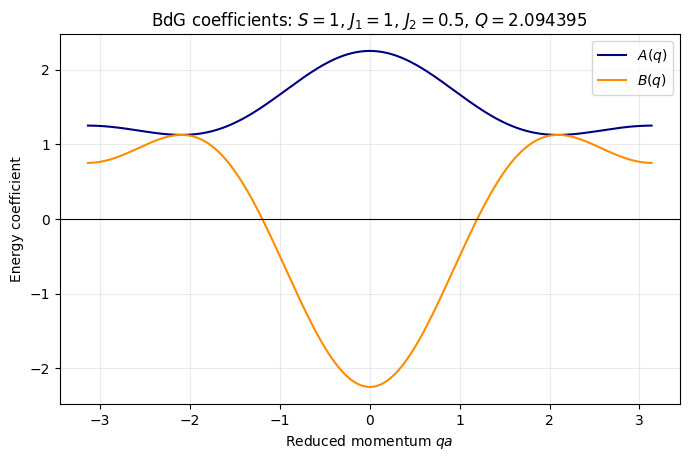

In [5]:
q_grid = centered_q_grid(n_q, lattice_constant)
A_values, B_values = lswt_coefficients(q_grid, S, J1, J2, Q, lattice_constant)
energy_compact = np.asarray(
    lswt_energy_compact(q_grid, S, J1, J2, Q, lattice_constant, tolerance),
    dtype=complex,
)
energy_from_AB = np.sqrt(np.clip(A_values**2 - B_values**2, 0.0, None))
AB_equivalence_error = float(np.max(np.abs(energy_compact - energy_from_AB)))

print(f"A/B versus compact J(k) maximum error: {AB_equivalence_error:.3e}")
print(f"q-grid contains q=0               : {np.any(np.isclose(q_grid, 0.0, atol=tolerance))}")
print(f"Duplicate periodic endpoint       : {np.isclose(q_grid[0], q_grid[-1], atol=tolerance)}")

fig, ax = plt.subplots()
ax.plot(q_grid * lattice_constant, A_values, label=r"$A(q)$", color="navy")
ax.plot(q_grid * lattice_constant, B_values, label=r"$B(q)$", color="darkorange")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set(
    xlabel=r"Reduced momentum $qa$",
    ylabel="Energy coefficient",
    title=fr"BdG coefficients: $S={S:g}$, $J_1={J1:g}$, $J_2={J2:g}$, $Q={Q:.6f}$",
)
ax.legend()
plt.show()


## 7. Hamiltonian bosonik BdG

Basis Nambu:

$$
\Psi_q=\begin{pmatrix}a_q\\a_{-q}^\dagger\end{pmatrix}.
$$

Hamiltonian:

$$
H_2=\frac12\sum_q\Psi_q^\dagger
\mathcal H_{\rm BdG}(q)\Psi_q+C,
$$

$$
\boxed{
\mathcal H_{\rm BdG}(q)=
\begin{pmatrix}
A(q)&B(q)\\
B(q)&A(q)
\end{pmatrix}
}.
$$

Matriks tersebut Hermitian. Namun energi magnon **bukan** ordinary Hermitian eigenvalue dari $\mathcal H_{\rm BdG}$.

Metrik bosonik:

$$
\eta=\begin{pmatrix}1&0\\0&-1\end{pmatrix}.
$$

Masalah eigenvalue yang benar:

$$
\eta\mathcal H_{\rm BdG}(q)t_n(q)=\varepsilon_n(q)t_n(q).
$$

Mode fisik harus sekaligus memenuhi

$$\varepsilon_n>0,\qquad t_n^\dagger\eta t_n>0,$$

kemudian dinormalisasi menjadi

$$t_n^\dagger\eta t_n=1.$$


## 8. Goldstone mode dan normalisasi bosonik

Pada exact Goldstone point, dynamic matrix dapat mempunyai zero eigenvalue dengan eigenvector zero-norm. Eigenvector tersebut tidak dapat dinormalisasi secara paraunitary dengan pembagian biasa.

Notebook ini memisahkan tiga objek:

1. **Energi fisik:** tetap disimpan tepat sebagai nol.
2. **Residual exact eigensystem:** dihitung dari masalah tanpa gap buatan.
3. **Eigenvector untuk matrix element spektral:** hanya pada exact zero-norm point digunakan $\mathcal H_{\rm BdG}+\delta_GI$, dengan `goldstone_regularization` yang dinyatakan eksplisit.

Regularisasi ini tidak menghapus Goldstone mode dan tidak mengubah kolom `energy`. Ia hanya mendefinisikan finite-resolution limit untuk bobot spektral dan Bose factor. Untuk spiral ini, zero mode diprediksi pada $q=0$ dan $q=\pm Q/a$.

Pada CSV, `exact_paraunitary_defined=False` menandai titik yang exact eigenvector-nya zero-norm. Di titik itu `paraunitary_error` berasal dari eigenvector regularized dan `paraunitary_source="goldstone-regularized"`; jadi tabel tetap finite tanpa menyamarkan asal nilai diagnostiknya.


Classical state       : spiral
Pitch Q               : 2.094395102393
Max Hermiticity error : 0.000e+00
Max BdG residual      : 5.448e-16
Max imaginary energy  : 9.587e-13
Eigenvalue pair error : 1.554e-15
Paraunitary error     : 2.098e-13
Periodicity error     : 1.533e-14
Minimum physical mode : 0.000e+00
Goldstones on grid    : 3


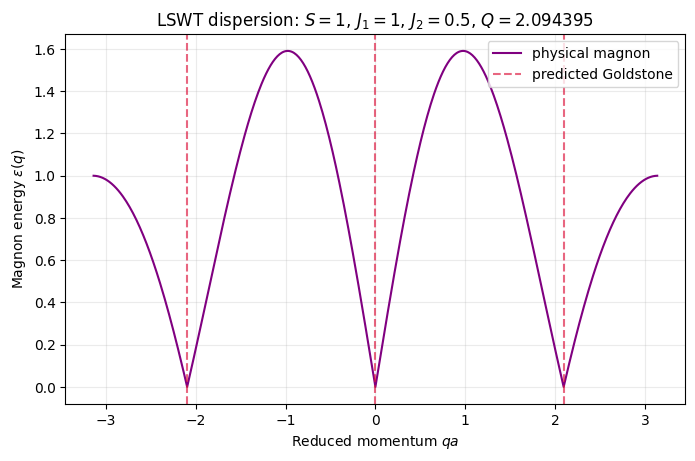

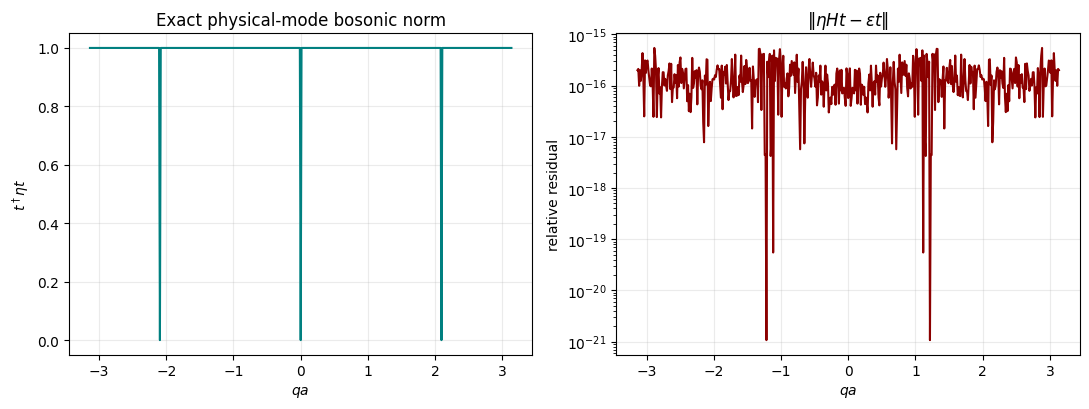

In [6]:
dispersion, numerical_diagnostics = solve_dispersion(q_grid, model, numerical, Q)

predicted_goldstones = np.array([0.0, Q / lattice_constant, -Q / lattice_constant])
predicted_goldstones = np.unique(np.round(wrap_momentum(predicted_goldstones, lattice_constant), 12))

print(f"Classical state       : {ground_state['phase']}")
print(f"Pitch Q               : {Q:.12f}")
print(f"Max Hermiticity error : {numerical_diagnostics['max_hermiticity_error']:.3e}")
print(f"Max BdG residual      : {numerical_diagnostics['max_bdg_residual']:.3e}")
print(f"Max imaginary energy  : {numerical_diagnostics['max_imaginary_energy']:.3e}")
print(f"Eigenvalue pair error : {numerical_diagnostics['max_pair_error']:.3e}")
print(f"Paraunitary error     : {numerical_diagnostics['max_paraunitary_error']:.3e}")
print(f"Periodicity error     : {numerical_diagnostics['periodicity_error']:.3e}")
print(f"Minimum physical mode : {numerical_diagnostics['minimum_energy']:.3e}")
print(f"Goldstones on grid    : {numerical_diagnostics['goldstone_count_on_grid']}")

fig, ax = plt.subplots()
ax.plot(dispersion["q"] * lattice_constant, dispersion["energy"], color="purple", label="physical magnon")
for index, point in enumerate(predicted_goldstones):
    ax.axvline(point * lattice_constant, color="crimson", linestyle="--", alpha=0.65,
               label="predicted Goldstone" if index == 0 else None)
ax.set(
    xlabel=r"Reduced momentum $qa$",
    ylabel=r"Magnon energy $\varepsilon(q)$",
    title=fr"LSWT dispersion: $S={S:g}$, $J_1={J1:g}$, $J_2={J2:g}$, $Q={Q:.6f}$",
)
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(dispersion["q"] * lattice_constant, dispersion["bosonic_norm"], color="teal")
axes[0].set(xlabel=r"$qa$", ylabel=r"$t^\dagger\eta t$", title="Exact physical-mode bosonic norm")
axes[1].semilogy(
    dispersion["q"] * lattice_constant,
    np.maximum(dispersion["residual"], np.finfo(float).tiny),
    color="darkred",
)
axes[1].set(xlabel=r"$qa$", ylabel="relative residual", title=r"$\|\eta Ht-\varepsilon t\|$")
plt.tight_layout()
plt.show()


## 9. Operator spin laboratorium dan matrix element satu-magnon

Karena

$$\mathbf S_j=R_y(Qj)\widetilde{\mathbf S}_j,$$

bagian linear operator laboratorium adalah

$$
S_j^x\simeq\cos(Qj)\sqrt{\frac S2}(a_j+a_j^\dagger),
$$

$$
S_j^y\simeq-i\sqrt{\frac S2}(a_j-a_j^\dagger),
$$

$$
S_j^z\simeq-\sin(Qj)\sqrt{\frac S2}(a_j+a_j^\dagger).
$$

Dengan

$$S^\alpha(k)=N^{-1/2}\sum_je^{-ikR_j}S_j^\alpha,$$

diperoleh

$$
S^x(k)=\sqrt{\frac S8}
\left[a_{k-Q/a}+a_{k+Q/a}+a_{-k+Q/a}^\dagger+a_{-k-Q/a}^\dagger\right],
$$

$$
S^y(k)=-i\sqrt{\frac S2}\left[a_k-a_{-k}^\dagger\right],
$$

$$
S^z(k)=i\sqrt{\frac S8}
\left[a_{k-Q/a}-a_{k+Q/a}+a_{-k+Q/a}^\dagger-a_{-k-Q/a}^\dagger\right].
$$

Jika positive-norm BdG eigenvector adalah $t_p=(u_p,v_p)^T$, matrix element dihitung dari koefisien operator di atas; tidak ada lagi asumsi $W_n(q)=1$.

Local longitudinal operator $\widetilde S^z=S-a^\dagger a$ tidak mempunyai kontribusi satu-magnon. Namun global $S^x$ dan $S^z$ mencampurkan local transverse operator untuk spiral, sehingga lab-frame $S^{zz}$ dapat memiliki kontribusi satu-magnon. Untuk $Q=0$, lab $z$ sama dengan local $z$ dan kontribusi satu-magnon $S^{zz}$ kembali nol.


## 10. Dynamical structure factor, temperatur, dan broadening

Matrix element

$$M_n^\alpha(q)=\langle n|S^\alpha(q)|0\rangle$$

menghasilkan

$$
S^{\alpha\beta}(q,\omega)=
\sum_nM_n^\alpha(q)^*M_n^\beta(q)
\delta[\omega-\varepsilon_n(q)].
$$

Untuk energy-loss neutron scattering $(\omega\ge0)$ pada temperatur finite, creation term dikalikan

$$n_B(\varepsilon)+1,$$

$$n_B(\varepsilon)=\frac1{\exp[\varepsilon/(k_BT)]-1}.$$

Annihilation term $n_B\delta(\omega+\varepsilon)$ berada pada negative energy transfer dan tidak dimasukkan ke plot default ini. Pada $T=0$, $n_B=0$.

Delta function dapat diganti Gaussian ternormalisasi

$$
\delta_\sigma(x)=\frac1{\sigma\sqrt{2\pi}}e^{-x^2/(2\sigma^2)},
$$

atau Lorentzian ternormalisasi

$$
\delta_\gamma(x)=\frac{\gamma}{\pi(x^2+\gamma^2)}.
$$

`raw_intensity` diekspor sebagai integrated line weight yang ditempatkan pada bin energi terdekat dan dibagi $\Delta\omega$. `broadened_intensity` adalah trace finite-temperature $S^{xx}+S^{yy}+S^{zz}$. Data mentah tidak dinormalisasi ke maksimum.


In [7]:
def gaussian_delta(x: Array, sigma: float) -> Array:
    """Normalized Gaussian representation of delta(x)."""

    if not np.isfinite(sigma) or sigma <= 0.0:
        raise ValueError("sigma must be finite and strictly positive.")
    x_array = np.asarray(x, dtype=float)
    return np.exp(-0.5 * (x_array / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


def lorentzian_delta(x: Array, gamma: float) -> Array:
    """Normalized Lorentzian representation of delta(x)."""

    if not np.isfinite(gamma) or gamma <= 0.0:
        raise ValueError("gamma must be finite and strictly positive.")
    x_array = np.asarray(x, dtype=float)
    return gamma / (np.pi * (x_array**2 + gamma**2))


def bose_occupation(
    energy: float | Array,
    temperature: float,
    k_B: float = 1.0,
    energy_floor: float = 0.0,
) -> float | Array:
    """Stable Bose occupation, with an explicit energy floor only for thermal evaluation."""

    energy_array = np.asarray(energy, dtype=float)
    if temperature < 0.0 or not np.isfinite(temperature):
        raise ValueError("temperature must be finite and nonnegative.")
    if k_B <= 0.0 or not np.isfinite(k_B):
        raise ValueError("k_B must be finite and strictly positive.")
    if temperature == 0.0:
        result = np.zeros_like(energy_array)
    else:
        evaluated_energy = np.maximum(energy_array, energy_floor)
        x = evaluated_energy / (k_B * temperature)
        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            result = np.where(x > 700.0, 0.0, 1.0 / np.expm1(x))
        result = np.where(evaluated_energy <= 0.0, np.inf, result)
    return float(result) if result.ndim == 0 else result


def magnetic_form_factor(
    q_absolute: float | Array,
    mode: str = "none",
    toy_gaussian_width: float = 0.1,
    custom_function: Callable[[Array], Array] | None = None,
) -> float | Array:
    """Return an amplitude form factor; the Gaussian option is explicitly nonphysical."""

    q_array = np.asarray(q_absolute, dtype=float)
    if mode == "none":
        result = np.ones_like(q_array)
    elif mode == "toy_gaussian":
        if toy_gaussian_width <= 0.0 or not np.isfinite(toy_gaussian_width):
            raise ValueError("toy_gaussian_width must be finite and positive.")
        result = np.exp(-toy_gaussian_width * q_array**2)
    elif mode == "custom":
        if custom_function is None:
            raise ValueError("custom_function is required when mode='custom'.")
        result = np.asarray(custom_function(q_array), dtype=float)
        if result.shape != q_array.shape:
            raise ValueError("custom form-factor function returned an incompatible shape.")
    else:
        raise ValueError("mode must be 'none', 'toy_gaussian', or 'custom'.")
    return float(result) if result.ndim == 0 else result


def polarization_projector(q_vector: Array | None) -> Array:
    """Return I-Qhat Qhat; None means polarization is intentionally disabled."""

    if q_vector is None:
        return np.eye(3)
    vector = np.asarray(q_vector, dtype=float)
    if vector.shape != (3,):
        raise ValueError("q_vector must contain exactly three Cartesian components.")
    norm = la.norm(vector)
    if norm == 0.0:
        raise ValueError("A nonzero absolute three-dimensional Q vector is required.")
    q_hat = vector / norm
    return np.eye(3) - np.outer(q_hat, q_hat)


def _momentum_key(q: float, lattice_constant: float) -> float:
    return round(float(wrap_momentum(q, lattice_constant)), 12)


def laboratory_spin_operator_terms(
    lab_q: float,
    Q: float,
    S: float,
    lattice_constant: float = 1.0,
) -> tuple[dict[float, Array], dict[float, Array]]:
    """Return coefficients of a_p and a_p^dagger in S_lab^alpha(q), alpha=x,y,z."""

    ann: dict[float, Array] = {}
    cre: dict[float, Array] = {}
    Q_wavevector = Q / lattice_constant
    transverse = np.sqrt(S / 2.0)
    shifted = transverse / 2.0

    def add(container: dict[float, Array], momentum: float, component: int, coefficient: complex) -> None:
        key = _momentum_key(momentum, lattice_constant)
        if key not in container:
            container[key] = np.zeros(3, dtype=complex)
        container[key][component] += coefficient

    add(ann, lab_q - Q_wavevector, 0, shifted)
    add(ann, lab_q + Q_wavevector, 0, shifted)
    add(cre, -lab_q + Q_wavevector, 0, shifted)
    add(cre, -lab_q - Q_wavevector, 0, shifted)

    add(ann, lab_q, 1, -1j * transverse)
    add(cre, -lab_q, 1, +1j * transverse)

    add(ann, lab_q - Q_wavevector, 2, +1j * shifted)
    add(ann, lab_q + Q_wavevector, 2, -1j * shifted)
    add(cre, -lab_q + Q_wavevector, 2, +1j * shifted)
    add(cre, -lab_q - Q_wavevector, 2, -1j * shifted)
    return ann, cre


def one_magnon_transitions(
    lab_q: float,
    model: ModelParameters,
    numerical: NumericalParameters,
    Q: float,
) -> list[dict[str, Any]]:
    """Compute one-magnon matrix elements <n|S_lab^alpha(q)|0> from BdG eigenvectors."""

    ann, cre = laboratory_spin_operator_terms(lab_q, Q, model.S, model.lattice_constant)
    possible_modes = {
        _momentum_key(-p, model.lattice_constant) for p in ann
    } | {
        _momentum_key(p, model.lattice_constant) for p in cre
    }
    transitions: list[dict[str, Any]] = []
    mode_cache: dict[float, dict[str, Any]] = {}

    def get_mode(momentum: float) -> dict[str, Any]:
        key = _momentum_key(momentum, model.lattice_constant)
        if key not in mode_cache:
            mode_cache[key] = physical_mode(key, model, numerical, Q, regularize_goldstone=True)
        return mode_cache[key]

    for mode_q in sorted(possible_modes):
        minus_mode_key = _momentum_key(-mode_q, model.lattice_constant)
        mode = get_mode(mode_q)
        minus_mode = get_mode(minus_mode_key)
        matrix_element = np.zeros(3, dtype=complex)
        if mode_q in cre:
            matrix_element += cre[mode_q] * np.conj(mode["u"])
        if minus_mode_key in ann:
            matrix_element += ann[minus_mode_key] * np.conj(minus_mode["v"])
        if la.norm(matrix_element) <= numerical.tolerance:
            continue
        tensor_weight = np.outer(np.conj(matrix_element), matrix_element)
        transitions.append(
            {
                "lab_q": float(lab_q),
                "mode_q": float(mode_q),
                "energy": float(np.real(mode["energy"])),
                "matrix_element": matrix_element,
                "tensor_weight": tensor_weight,
                "spectral_regularized": bool(mode["regularized"] or minus_mode["regularized"]),
            }
        )
    return transitions


def compute_dynamical_structure_factor(
    q_grid: Array,
    model: ModelParameters,
    numerical: NumericalParameters,
    Q: float,
    broadening_kind: str = "gaussian",
    form_factor_mode: str = "none",
    toy_form_factor_width: float = 0.1,
    absolute_q_vectors: Array | None = None,
) -> dict[str, Any]:
    """Compute one-magnon S^{alpha beta}(q,omega) and a configurable neutron intensity."""

    q_values = np.asarray(q_grid, dtype=float)
    transitions_by_q = [one_magnon_transitions(q, model, numerical, Q) for q in q_values]
    all_energies = [item["energy"] for group in transitions_by_q for item in group]
    maximum_mode_energy = max(all_energies, default=0.0)
    omega_max = numerical.omega_max
    if omega_max is None:
        omega_max = max(10.0 * numerical.broadening, maximum_mode_energy + 8.0 * numerical.broadening)
    omega_grid = np.linspace(0.0, float(omega_max), numerical.n_omega)
    delta_omega = float(omega_grid[1] - omega_grid[0])

    if broadening_kind == "gaussian":
        broadener = gaussian_delta
    elif broadening_kind == "lorentzian":
        broadener = lorentzian_delta
    else:
        raise ValueError("broadening_kind must be 'gaussian' or 'lorentzian'.")

    tensor_zero_temperature = np.zeros((len(q_values), len(omega_grid), 3, 3), dtype=complex)
    tensor_finite_temperature = np.zeros_like(tensor_zero_temperature)
    raw_binned = np.zeros((len(q_values), len(omega_grid)), dtype=float)
    transition_rows: list[dict[str, Any]] = []

    for iq, transitions in enumerate(transitions_by_q):
        for transition in transitions:
            energy = transition["energy"]
            evaluated_energy = float(np.sqrt(energy**2 + numerical.goldstone_regularization**2))
            occupation = bose_occupation(
                evaluated_energy,
                numerical.temperature,
                numerical.k_B,
                numerical.goldstone_regularization,
            )
            creation_factor = float(occupation + 1.0)
            profile = broadener(omega_grid - energy, numerical.broadening)
            weight = transition["tensor_weight"]
            tensor_zero_temperature[iq] += profile[:, None, None] * weight[None, :, :]
            tensor_finite_temperature[iq] += (
                creation_factor * profile[:, None, None] * weight[None, :, :]
            )
            nearest_bin = int(np.argmin(np.abs(omega_grid - energy)))
            raw_binned[iq, nearest_bin] += float(np.real(np.trace(weight))) / delta_omega
            transition_rows.append(
                {
                    "q": q_values[iq],
                    "mode_q": transition["mode_q"],
                    "energy": energy,
                    "M_x_real": np.real(transition["matrix_element"][0]),
                    "M_x_imag": np.imag(transition["matrix_element"][0]),
                    "M_y_real": np.real(transition["matrix_element"][1]),
                    "M_y_imag": np.imag(transition["matrix_element"][1]),
                    "M_z_real": np.real(transition["matrix_element"][2]),
                    "M_z_imag": np.imag(transition["matrix_element"][2]),
                    "weight_xx": np.real(weight[0, 0]),
                    "weight_yy": np.real(weight[1, 1]),
                    "weight_zz": np.real(weight[2, 2]),
                    "bose_creation_factor": creation_factor,
                    "spectral_regularized": transition["spectral_regularized"],
                }
            )

    Sxx = np.real(tensor_finite_temperature[:, :, 0, 0])
    Syy = np.real(tensor_finite_temperature[:, :, 1, 1])
    Szz = np.real(tensor_finite_temperature[:, :, 2, 2])
    S_transverse = Sxx + Syy
    broadened_total = Sxx + Syy + Szz

    if absolute_q_vectors is not None:
        q_vectors = np.asarray(absolute_q_vectors, dtype=float)
        if q_vectors.shape != (len(q_values), 3):
            raise ValueError("absolute_q_vectors must have shape (len(q_grid), 3).")
    else:
        q_vectors = None

    structure_factor = np.zeros_like(broadened_total)
    thermal_projected = np.zeros_like(broadened_total)
    polarization_factor = np.ones_like(broadened_total)
    form_factor_values = np.ones(len(q_values), dtype=float)
    neutron_intensity = np.zeros_like(broadened_total)

    for iq, q in enumerate(q_values):
        projector = polarization_projector(None if q_vectors is None else q_vectors[iq])
        zero_projected = np.real(np.einsum("ab,wab->w", projector, tensor_zero_temperature[iq]))
        finite_projected = np.real(np.einsum("ab,wab->w", projector, tensor_finite_temperature[iq]))
        zero_trace = np.real(np.trace(tensor_zero_temperature[iq], axis1=1, axis2=2))
        structure_factor[iq] = zero_projected
        thermal_projected[iq] = finite_projected
        polarization_factor[iq] = np.divide(
            zero_projected,
            zero_trace,
            out=np.ones_like(zero_projected),
            where=np.abs(zero_trace) > numerical.tolerance,
        )
        q_absolute = la.norm(q_vectors[iq]) if q_vectors is not None else abs(q)
        form_factor_values[iq] = magnetic_form_factor(
            q_absolute,
            form_factor_mode,
            toy_form_factor_width,
        )
        neutron_intensity[iq] = form_factor_values[iq] ** 2 * finite_projected

    effective_bose_factor = np.divide(
        thermal_projected,
        structure_factor,
        out=np.ones_like(thermal_projected),
        where=np.abs(structure_factor) > numerical.tolerance,
    )

    q_mesh, omega_mesh = np.meshgrid(q_values, omega_grid, indexing="ij")
    dsf_table = pd.DataFrame(
        {
            "q": q_mesh.ravel(),
            "omega": omega_mesh.ravel(),
            "Sxx": Sxx.ravel(),
            "Syy": Syy.ravel(),
            "Szz": Szz.ravel(),
            "S_transverse": S_transverse.ravel(),
            "raw_intensity": raw_binned.ravel(),
            "broadened_intensity": broadened_total.ravel(),
        }
    )
    neutron_table = pd.DataFrame(
        {
            "q": q_mesh.ravel(),
            "omega": omega_mesh.ravel(),
            "structure_factor": structure_factor.ravel(),
            "bose_factor": effective_bose_factor.ravel(),
            "magnetic_form_factor": np.repeat(form_factor_values, len(omega_grid)),
            "polarization_factor": polarization_factor.ravel(),
            "neutron_intensity": neutron_intensity.ravel(),
        }
    )

    return {
        "omega_grid": omega_grid,
        "S_tensor_zero_temperature": tensor_zero_temperature,
        "S_tensor": tensor_finite_temperature,
        "Sxx": Sxx,
        "Syy": Syy,
        "Szz": Szz,
        "S_transverse": S_transverse,
        "raw_intensity": raw_binned,
        "broadened_intensity": broadened_total,
        "structure_factor": structure_factor,
        "bose_factor": effective_bose_factor,
        "form_factor": form_factor_values,
        "polarization_factor": polarization_factor,
        "neutron_intensity": neutron_intensity,
        "transitions": pd.DataFrame(transition_rows),
        "dynamical_structure_factor_table": dsf_table,
        "neutron_intensity_table": neutron_table,
    }


## 11. Magnetic form factor dan polarization factor neutron

Cross-section magnetik unpolarized memiliki bentuk

$$
I(\mathbf Q,\omega)\propto
|f(\mathbf Q)|^2
\sum_{\alpha\beta}
(\delta_{\alpha\beta}-\widehat Q_\alpha\widehat Q_\beta)
S^{\alpha\beta}(\mathbf Q,\omega).
$$

Pilihan notebook:

- `form_factor_mode="none"`: $f=1$.
- `form_factor_mode="toy_gaussian"`: contoh nonfisik $f=e^{-c|\mathbf Q|^2}$, diberi label toy.
- `form_factor_mode="custom"`: pengguna memasukkan fungsi ion sebenarnya.

Polarization factor hanya diaktifkan jika pengguna menyediakan `absolute_q_vectors` berukuran `(n_q, 3)`. Reduced momentum rantai saja tidak cukup menentukan projector neutron tiga dimensi.


One-magnon transitions : 1511
DSF table rows         : 300,600
Omega range            : [0, 1.83098]
Temperature            : 0 energy/k_B
Broadening             : gaussian, width=0.03
Form factor            : none
Polarization projector : disabled


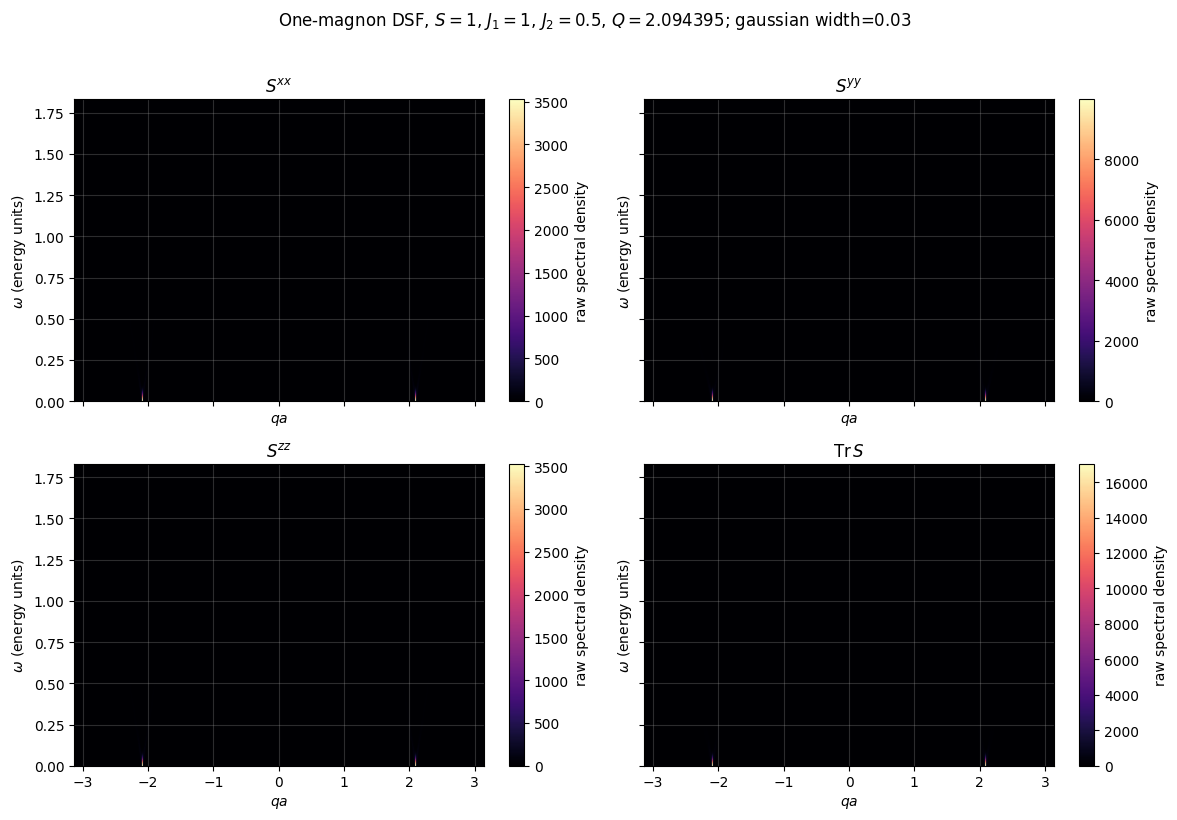

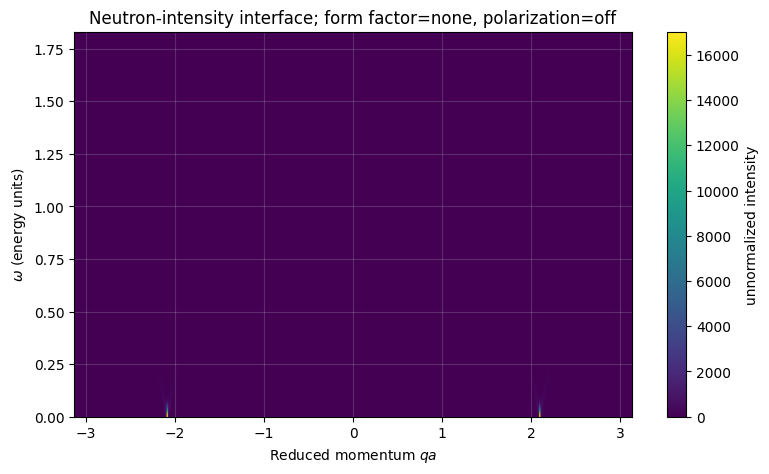

In [8]:
spectral = compute_dynamical_structure_factor(
    q_grid=q_grid,
    model=model,
    numerical=numerical,
    Q=Q,
    broadening_kind=broadening_kind,
    form_factor_mode=form_factor_mode,
    toy_form_factor_width=toy_form_factor_width,
    absolute_q_vectors=absolute_q_vectors,
)
omega_grid = spectral["omega_grid"]

print(f"One-magnon transitions : {len(spectral['transitions'])}")
print(f"DSF table rows         : {len(spectral['dynamical_structure_factor_table']):,}")
print(f"Omega range            : [{omega_grid[0]:.6g}, {omega_grid[-1]:.6g}]")
print(f"Temperature            : {temperature:g} energy/k_B")
print(f"Broadening             : {broadening_kind}, width={broadening:g}")
print(f"Form factor            : {form_factor_mode}")
print(f"Polarization projector : {'disabled' if absolute_q_vectors is None else 'enabled'}")

extent = [q_grid[0] * lattice_constant, q_grid[-1] * lattice_constant, omega_grid[0], omega_grid[-1]]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
maps = [
    (spectral["Sxx"], r"$S^{xx}$"),
    (spectral["Syy"], r"$S^{yy}$"),
    (spectral["Szz"], r"$S^{zz}$"),
    (spectral["broadened_intensity"], r"$\mathrm{Tr}\,S$"),
]
for ax, (values, title) in zip(axes.flat, maps):
    image = ax.imshow(values.T, origin="lower", aspect="auto", extent=extent, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel(r"$qa$")
    ax.set_ylabel(r"$\omega$ (energy units)")
    fig.colorbar(image, ax=ax, label="raw spectral density")
fig.suptitle(
    fr"One-magnon DSF, $S={S:g}$, $J_1={J1:g}$, $J_2={J2:g}$, "
    fr"$Q={Q:.6f}$; {broadening_kind} width={broadening:g}",
    y=1.02,
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(
    spectral["neutron_intensity"].T,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="viridis",
)
ax.set(
    xlabel=r"Reduced momentum $qa$",
    ylabel=r"$\omega$ (energy units)",
    title=(
        f"Neutron-intensity interface; form factor={form_factor_mode}, "
        f"polarization={'off' if absolute_q_vectors is None else 'on'}"
    ),
)
fig.colorbar(image, ax=ax, label="unnormalized intensity")
plt.show()


## 12. Validasi analitik dan numerik

Automated tests mencakup:

1. Feromagnet nearest-neighbor, $J_1=-1,J_2=0,Q=0$:
   $$\varepsilon(q)=2S[1-\cos(qa)]$$
   dan stiffness panjang-gelombang kuadratik.
2. Antiferomagnet nearest-neighbor, $J_1=1,J_2=0,Q=\pi$:
   $$\varepsilon(q)=2S|\sin(qa)|$$
   dan slope linear dekat Goldstone.
3. Spiral $J_1=1,J_2=0.5$:
   $$Q=2\pi/3,$$
   minimum klasik global dan zero modes pada $0,\pm Q/a$.
4. Batas fase $|J_1/(4J_2)|=1$ dan titik sangat dekat batas.
5. Hermiticity, residual eigenproblem, pasangan $\pm\varepsilon$, paraunitarity, periodisitas, nonnegativitas, normalisasi broadening, Hermiticity tensor spektral, serta sum rule satu-magnon feromagnet.


In [9]:
def run_analytic_validation(tolerance: float = 1.0e-9) -> pd.DataFrame:
    """Run mandatory FM, AF, spiral, and phase-boundary regression tests."""

    cases: list[dict[str, Any]] = []
    q = np.linspace(-np.pi, np.pi, 1201, endpoint=False)
    S = 1.0

    ground_fm = find_classical_ground_state(S, -1.0, 0.0, tolerance)
    energy_fm = np.asarray(lswt_energy_compact(q, S, -1.0, 0.0, ground_fm["Q"], tolerance=tolerance))
    expected_fm = 2.0 * S * (1.0 - np.cos(q))
    fm_error = float(np.max(np.abs(energy_fm - expected_fm)))
    small_q = 1.0e-4
    stiffness = float(lswt_energy_compact(small_q, S, -1.0, 0.0, 0.0) / small_q**2)
    assert ground_fm["phase"] == "ferromagnetic"
    assert fm_error < 100.0 * tolerance
    assert abs(stiffness - S) < 1.0e-6
    cases.append({"case": "nearest-neighbor ferromagnet", "status": "PASS", "max_error": fm_error})

    ground_af = find_classical_ground_state(S, 1.0, 0.0, tolerance)
    energy_af = np.asarray(lswt_energy_compact(q, S, 1.0, 0.0, ground_af["Q"], tolerance=tolerance))
    expected_af = 2.0 * S * np.abs(np.sin(q))
    af_error = float(np.max(np.abs(energy_af - expected_af)))
    slope = float(lswt_energy_compact(small_q, S, 1.0, 0.0, np.pi) / small_q)
    assert ground_af["phase"] == "antiferromagnetic"
    assert af_error < 100.0 * tolerance
    assert abs(slope - 2.0 * S) < 1.0e-6
    cases.append({"case": "nearest-neighbor antiferromagnet", "status": "PASS", "max_error": af_error})

    ground_spiral = find_classical_ground_state(S, 1.0, 0.5, tolerance)
    assert ground_spiral["phase"] == "spiral"
    assert abs(ground_spiral["Q"] - 2.0 * np.pi / 3.0) < 100.0 * tolerance
    zero_points = np.array([0.0, ground_spiral["Q"], -ground_spiral["Q"]])
    spiral_zeros = np.asarray(
        lswt_energy_compact(zero_points, S, 1.0, 0.5, ground_spiral["Q"], tolerance=tolerance)
    )
    spiral_zero_error = float(np.max(np.abs(spiral_zeros)))
    assert spiral_zero_error < 1.0e-7
    assert abs(ground_spiral["pitch_derivative"]) < 100.0 * tolerance
    cases.append({"case": "J1-J2 spiral", "status": "PASS", "max_error": spiral_zero_error})

    boundary = find_classical_ground_state(S, -4.0, 1.0, tolerance)
    near_boundary = find_classical_ground_state(S, -4.0 * (1.0 - 1.0e-12), 1.0, tolerance)
    boundary_energies = np.asarray(
        lswt_energy_compact(q, S, -4.0, 1.0, boundary["Q"], tolerance=1.0e-8), dtype=complex
    )
    boundary_imaginary = float(np.max(np.abs(np.imag(boundary_energies))))
    assert boundary["phase"] == "ferromagnetic"
    assert near_boundary["Q"] >= 0.0
    assert boundary_imaginary < 1.0e-8
    cases.append({"case": "phase boundary |J1/(4J2)|=1", "status": "PASS", "max_error": boundary_imaginary})

    return pd.DataFrame(cases)


analytic_validation = run_analytic_validation(tolerance=1.0e-9)

# Numerical assertions for the active model.
assert AB_equivalence_error < 100.0 * tolerance
assert numerical_diagnostics["max_hermiticity_error"] < 100.0 * tolerance
assert numerical_diagnostics["max_bdg_residual"] < 100.0 * tolerance
assert numerical_diagnostics["max_imaginary_energy"] < 100.0 * tolerance
assert numerical_diagnostics["max_pair_error"] < 100.0 * tolerance
assert numerical_diagnostics["max_paraunitary_error"] < 1000.0 * tolerance
assert numerical_diagnostics["periodicity_error"] < 1000.0 * tolerance
assert numerical_diagnostics["minimum_energy"] >= -100.0 * tolerance
assert abs(ground_state["pitch_derivative"]) < 1000.0 * tolerance

# Broadening normalization.
x_test = np.linspace(-20.0 * broadening, 20.0 * broadening, 200_001)
gaussian_integral = float(np.trapezoid(gaussian_delta(x_test, broadening), x_test))
assert abs(gaussian_integral - 1.0) < 1.0e-8

# Spectral tensor Hermiticity and positivity of diagonal components.
tensor = spectral["S_tensor"]
tensor_hermiticity_error = float(np.max(np.abs(tensor - np.swapaxes(tensor.conj(), 2, 3))))
minimum_diagonal_intensity = float(
    min(np.min(spectral["Sxx"]), np.min(spectral["Syy"]), np.min(spectral["Szz"]))
)
assert tensor_hermiticity_error < 1000.0 * tolerance
assert minimum_diagonal_intensity >= -1000.0 * tolerance

# Exact one-magnon transverse sum rule in the collinear FM limit.
fm_model = ModelParameters(S=1.0, J1=-1.0, J2=0.0, lattice_constant=1.0)
fm_numerical = NumericalParameters(n_q=101, n_omega=101, broadening=0.03, tolerance=tolerance)
fm_transitions = one_magnon_transitions(0.37, fm_model, fm_numerical, Q=0.0)
fm_one_magnon_weight = float(sum(np.real(np.trace(item["tensor_weight"])) for item in fm_transitions))
assert abs(fm_one_magnon_weight - fm_model.S) < 100.0 * tolerance

current_validation = pd.DataFrame([
    {"test": "A/B equals compact J(k)", "value": AB_equivalence_error, "limit": 100.0 * tolerance, "status": "PASS"},
    {"test": "BdG Hermiticity", "value": numerical_diagnostics["max_hermiticity_error"], "limit": 100.0 * tolerance, "status": "PASS"},
    {"test": "BdG residual", "value": numerical_diagnostics["max_bdg_residual"], "limit": 100.0 * tolerance, "status": "PASS"},
    {"test": "imaginary energy", "value": numerical_diagnostics["max_imaginary_energy"], "limit": 100.0 * tolerance, "status": "PASS"},
    {"test": "paraunitary error", "value": numerical_diagnostics["max_paraunitary_error"], "limit": 1000.0 * tolerance, "status": "PASS"},
    {"test": "periodicity", "value": numerical_diagnostics["periodicity_error"], "limit": 1000.0 * tolerance, "status": "PASS"},
    {"test": "Gaussian integral", "value": abs(gaussian_integral - 1.0), "limit": 1.0e-8, "status": "PASS"},
    {"test": "spectral tensor Hermiticity", "value": tensor_hermiticity_error, "limit": 1000.0 * tolerance, "status": "PASS"},
    {"test": "FM one-magnon transverse sum rule", "value": abs(fm_one_magnon_weight - fm_model.S), "limit": 100.0 * tolerance, "status": "PASS"},
])

display(analytic_validation)
display(current_validation)
print("Validation status: PASS")


,case,status,max_error
0,nearest-neighbor ferromagnet,PASS,0.000000e+00
1,nearest-neighbor antiferromagnet,PASS,3.129181e-14
2,J1-J2 spiral,PASS,0.000000e+00
3,phase boundary |J1/(4J2)|=1,PASS,0.000000e+00


,test,value,limit,status
0,A/B equals compact J(k),3.589490e-14,1.000000e-08,PASS
1,BdG Hermiticity,0.000000e+00,1.000000e-08,PASS
2,BdG residual,5.447727e-16,1.000000e-08,PASS
3,imaginary energy,9.586554e-13,1.000000e-08,PASS
4,paraunitary error,2.098001e-13,1.000000e-07,PASS
5,periodicity,1.533496e-14,1.000000e-07,PASS
6,Gaussian integral,2.220446e-16,1.000000e-08,PASS
7,spectral tensor Hermiticity,9.487409e-32,1.000000e-07,PASS
8,FM one-magnon transverse sum rule,2.220446e-16,1.000000e-08,PASS


Validation status: PASS


## 13. Ekspor data reproducible

Notebook menulis data ke folder `lswt_outputs` relatif terhadap working directory eksekusi dan mencetak path absolutnya. Tidak ada normalisasi ke nilai maksimum sebelum ekspor.

File wajib:

- `classical_ground_state.csv`
- `spin_wave_dispersion.csv`
- `dynamical_structure_factor.csv`
- `neutron_intensity.csv`

File tambahan:

- `one_magnon_matrix_elements.csv`
- `validation_results.csv`


In [10]:
OUTPUT_DIR = Path("lswt_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

classical_ground_state_table = pd.DataFrame([
    {
        "phase": ground_state["phase"],
        "Q": Q,
        "classical_energy": ground_state["energy"],
        "J1": J1,
        "J2": J2,
        "S": S,
    }
])

validation_results = pd.concat(
    [
        analytic_validation.rename(columns={"case": "test", "max_error": "value"})[["test", "status", "value"]],
        current_validation[["test", "status", "value"]],
    ],
    ignore_index=True,
)

export_tables = {
    "classical_ground_state.csv": classical_ground_state_table,
    "spin_wave_dispersion.csv": dispersion,
    "dynamical_structure_factor.csv": spectral["dynamical_structure_factor_table"],
    "neutron_intensity.csv": spectral["neutron_intensity_table"],
    "one_magnon_matrix_elements.csv": spectral["transitions"],
    "validation_results.csv": validation_results,
}

for filename, table in export_tables.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False, float_format="%.12g")
    print(f"Wrote {path.resolve()} ({len(table):,} rows, {path.stat().st_size / 1024**2:.2f} MiB)")


Wrote /Users/genius/Documents/Codex/2026-07-23/hi-2/outputs/lswt_outputs/classical_ground_state.csv (1 rows, 0.00 MiB)
Wrote /Users/genius/Documents/Codex/2026-07-23/hi-2/outputs/lswt_outputs/spin_wave_dispersion.csv (501 rows, 0.10 MiB)


Wrote /Users/genius/Documents/Codex/2026-07-23/hi-2/outputs/lswt_outputs/dynamical_structure_factor.csv (300,600 rows, 32.40 MiB)


Wrote /Users/genius/Documents/Codex/2026-07-23/hi-2/outputs/lswt_outputs/neutron_intensity.csv (300,600 rows, 19.51 MiB)
Wrote /Users/genius/Documents/Codex/2026-07-23/hi-2/outputs/lswt_outputs/one_magnon_matrix_elements.csv (1,511 rows, 0.20 MiB)
Wrote /Users/genius/Documents/Codex/2026-07-23/hi-2/outputs/lswt_outputs/validation_results.csv (13 rows, 0.00 MiB)


## 14. Perbandingan hasil lama dan baru

- Untuk parameter default $S=1,J_1=1,J_2=0.5$, keduanya memperoleh $Q=2\pi/3$ dan dispersi energi yang sama karena bentuk lama $A(q),B(q)$ memang konsisten dengan konvensi bond-once.
- Notebook lama gagal memilih AF ketika spiral tidak tersedia; notebook baru membandingkan seluruh stationary candidate secara global.
- Notebook lama hanya menyortir eigenvalue; notebook baru memilih positive-energy/positive-norm mode, menormalisasi dengan $\eta$, dan menguji residual serta paraunitarity.
- Notebook lama menghapus Goldstone dari intensitas; notebook baru mempertahankan energi nol dan menandai regularisasi eigenvector spektral secara terpisah.
- Notebook lama memakai $W_n=1$; notebook baru menghitung $u,v$, operator spin laboratorium, dan matrix element setiap transition.
- Notebook lama hanya mempunyai satu peta fenomenologis; notebook baru mengekspor $S^{xx},S^{yy},S^{zz}$, tensor untuk polarization contraction, data mentah, data broadened, dan interface neutron.

## 15. Batasan model

- Model masih satu dimensi dan hanya mempunyai satu spin per primitive cell.
- LSWT mengabaikan interaksi magnon orde lebih tinggi dan finite-lifetime self-energy.
- Local longitudinal $\widetilde S^{zz}$ membutuhkan kontribusi dua-magnon pada leading inelastic order; notebook ini hanya menghitung one-magnon sector.
- Lab-frame $S^{zz}$ dapat memperoleh one-magnon weight melalui rotasi spiral, tetapi ini bukan pengganti longitudinal two-magnon continuum.
- Absolute neutron cross-section memerlukan normalisasi eksperimental, $g$-tensor, Debye-Waller factor, jumlah ion, dan prefaktor instrumen.
- Form factor fisik membutuhkan identitas ion magnetik dan absolute $|\mathbf Q|$.
- Polarization factor membutuhkan geometri transfer momentum tiga dimensi.
- Exact Goldstone eigenvector bersifat singular dalam basis Bogoliubov; regularisasi yang tercatat hanya merepresentasikan finite-resolution spectral limit.
- Zero-point correction terhadap energi/magnetisasi dan koreksi orde $1/S$ belum dimasukkan.

Dengan batasan tersebut, notebook ini merupakan fondasi LSWT satu-magnon dan simulasi dynamical structure factor, bukan klaim simulasi neutron absolut yang lengkap.
